### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load and clean data

In [7]:
df = pd.read_csv('china_gdp.csv')
df.head()

,Year,Value
0,1960,5.918412e+10
1,1961,4.955705e+10
2,1962,4.668518e+10
3,1963,5.009730e+10
4,1964,5.906225e+10


In [13]:
x_data, y_data = (df["Year"].values, df["Value"].values)

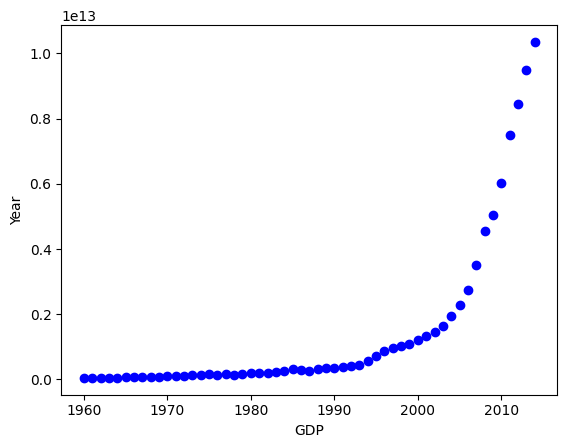

In [17]:
plt.plot(x_data, y_data, 'bo')
plt.xlabel ('GDP')
plt.ylabel ('Year')
plt.show()

Since the plot resembles a sigmoid shape (also consider that the GDP could not grow exponentially!), we use the sigmoid function to model the nonlinear regression.

### Bilding the model

In [21]:
def sigmoid(x, Beta_1, Beta_2):
     y = 1 / (1 + np.exp(-Beta_1*(x-Beta_2)))
     return y

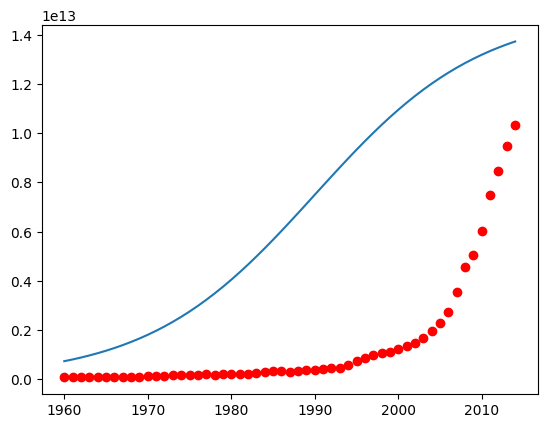

In [23]:
beta_1 = 0.10
beta_2 = 1990.0

#logistic function
Y_pred = sigmoid(x_data, beta_1 , beta_2)

#plot initial prediction against datapoints
plt.plot(x_data, Y_pred*15000000000000.)
plt.plot(x_data, y_data, 'ro')

### Normalize the data

In [26]:
xdata =x_data/max(x_data)
ydata =y_data/max(y_data)

In [28]:
from scipy.optimize import curve_fit
popt, pcov = curve_fit(sigmoid, xdata, ydata)
#print the final parameters
print(" beta_1 = %f, beta_2 = %f" % (popt[0], popt[1]))

 beta_1 = 690.451714, beta_2 = 0.997207


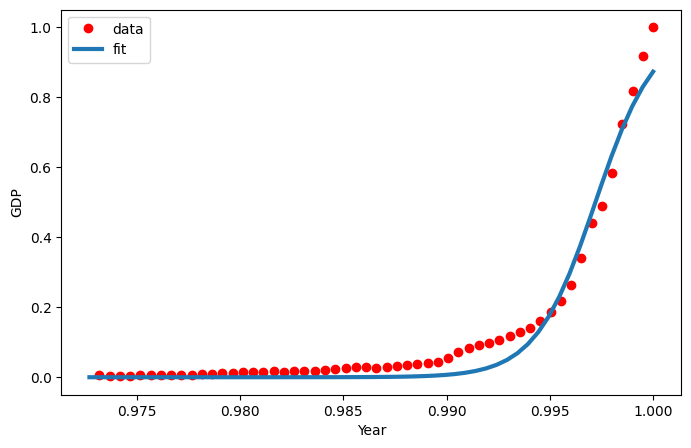

In [30]:
x = np.linspace(1960, 2015, 55)
x = x/max(x)
plt.figure(figsize=(8,5))
y = sigmoid(x, *popt)
plt.plot(xdata, ydata, 'ro', label='data')
plt.plot(x,y, linewidth=3.0, label='fit')
plt.legend(loc='best')
plt.ylabel('GDP')
plt.xlabel('Year')
plt.show()

### Evaluation

In [33]:
from sklearn.metrics import r2_score

r2 = r2_score(ydata, y)
print(f"R^2 Score: {r2:.2f}")

R^2 Score: 0.97
